# RoBERTa Fine-tuning — Creativity Score Prediction
---
This notebook fine-tunes **RoBERTa-base** to predict creativity scores from raw story text.

**Architecture:** `[Story Text] → RoBERTa Tokenizer → RoBERTa-base → [CLS] → Linear(768→1) → Score (0–10)`

⚠️ **Before running:** Make sure `train.parquet`, `val.parquet`, and `test.parquet` are in `data/processed/`.

⏱️ **Expected time:** ~45 min – 1.5 hrs on RTX 5070


In [1]:
# ── Imports ──
import os
import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import (
    RobertaTokenizer, RobertaForSequenceClassification,
    get_linear_schedule_with_warmup
)
from torch.optim import AdamW
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import time, gc

# Local paths
DATA_DIR = os.path.join("..", "data", "processed")
MODEL_DIR = os.path.join("..", "data", "models")
os.makedirs(MODEL_DIR, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")


Device: cuda
GPU: NVIDIA GeForce RTX 5070
Memory: 12.8 GB


In [2]:
# ── Load Data ──
train_df = pd.read_parquet(f'{DATA_DIR}/train.parquet')
val_df   = pd.read_parquet(f'{DATA_DIR}/val.parquet')
test_df  = pd.read_parquet(f'{DATA_DIR}/test.parquet')

TEXT_COL = 'story_truncated'
TARGET_COL = 'composite_score'

print(f"Train: {len(train_df)}  Val: {len(val_df)}  Test: {len(test_df)}")
print(f"\nComposite score stats (train):")
print(train_df[TARGET_COL].describe().round(2))


Train: 190805  Val: 40887  Test: 40887

Composite score stats (train):
count    190805.00
mean          3.63
std           1.27
min           0.00
25%           2.74
50%           3.53
75%           4.43
max          10.00
Name: composite_score, dtype: float64


In [3]:
# ── PyTorch Dataset ──
class StoryDataset(Dataset):
    def __init__(self, texts, scores, tokenizer, max_length=512):
        self.texts = texts
        self.scores = scores
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'labels': torch.tensor(self.scores[idx], dtype=torch.float32)
        }

tokenizer = RobertaTokenizer.from_pretrained('roberta-base')

train_dataset = StoryDataset(
    train_df[TEXT_COL].tolist(),
    train_df[TARGET_COL].tolist(),
    tokenizer
)
val_dataset = StoryDataset(
    val_df[TEXT_COL].tolist(),
    val_df[TARGET_COL].tolist(),
    tokenizer
)
test_dataset = StoryDataset(
    test_df[TEXT_COL].tolist(),
    test_df[TARGET_COL].tolist(),
    tokenizer
)

BATCH_SIZE = 16  # T4 can handle 16 with RoBERTa-base
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, num_workers=0)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, num_workers=0)

print(f"Batches per epoch: {len(train_loader)}")
print("Datasets ready.")


Batches per epoch: 11926
Datasets ready.


In [4]:
# ── Load RoBERTa for Regression ──
model = RobertaForSequenceClassification.from_pretrained(
    'roberta-base',
    num_labels=1,           # regression (single continuous output)
    problem_type='regression'
)
model = model.to(device)

trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {trainable_params:,}")


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Trainable parameters: 124,646,401


In [5]:
# ── Training Config ──
EPOCHS = 3
LR = 2e-5
WARMUP_RATIO = 0.1

optimizer = AdamW(model.parameters(), lr=LR, weight_decay=0.01)
total_steps = len(train_loader) * EPOCHS
warmup_steps = int(total_steps * WARMUP_RATIO)
scheduler = get_linear_schedule_with_warmup(optimizer, warmup_steps, total_steps)

print(f"Total training steps: {total_steps}")
print(f"Warmup steps: {warmup_steps}")


Total training steps: 35778
Warmup steps: 3577


In [6]:
# ── Training Loop ──
train_losses = []
val_losses = []
best_val_loss = float('inf')
save_path = f'{MODEL_DIR}/roberta_best.pt'

for epoch in range(EPOCHS):
    # ── Train ──
    model.train()
    epoch_loss = 0
    t0 = time.time()

    for step, batch in enumerate(train_loader):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        epoch_loss += loss.item()

        if (step + 1) % 200 == 0:
            elapsed = time.time() - t0
            steps_per_sec = (step + 1) / elapsed
            eta_min = (len(train_loader) - step - 1) / steps_per_sec / 60
            print(f"  Epoch {epoch+1} step {step+1}/{len(train_loader)}  "
                  f"loss={loss.item():.4f}  "
                  f"lr={scheduler.get_last_lr()[0]:.2e}  "
                  f"ETA: {eta_min:.0f}min")

    avg_train_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # ── Validate ──
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            val_loss += outputs.loss.item()

    avg_val_loss = val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    elapsed = time.time() - t0
    print(f"\nEpoch {epoch+1}/{EPOCHS}  "
          f"train_loss={avg_train_loss:.4f}  "
          f"val_loss={avg_val_loss:.4f}  "
          f"time={elapsed/60:.1f}min")

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), save_path)
        print(f"  → Saved best model (val_loss={best_val_loss:.4f})")

    # Free up memory
    gc.collect()
    torch.cuda.empty_cache()

print(f"\nTraining complete. Best val loss: {best_val_loss:.4f}")


  Epoch 1 step 200/11926  loss=3.3109  lr=1.12e-06  ETA: 76min
  Epoch 1 step 400/11926  loss=0.9877  lr=2.24e-06  ETA: 74min
  Epoch 1 step 600/11926  loss=0.4807  lr=3.35e-06  ETA: 72min
  Epoch 1 step 800/11926  loss=0.4728  lr=4.47e-06  ETA: 71min
  Epoch 1 step 1000/11926  loss=0.2777  lr=5.59e-06  ETA: 70min
  Epoch 1 step 1200/11926  loss=0.5151  lr=6.71e-06  ETA: 68min
  Epoch 1 step 1400/11926  loss=0.2653  lr=7.83e-06  ETA: 67min
  Epoch 1 step 1600/11926  loss=0.5745  lr=8.95e-06  ETA: 66min
  Epoch 1 step 1800/11926  loss=0.6197  lr=1.01e-05  ETA: 64min
  Epoch 1 step 2000/11926  loss=0.8146  lr=1.12e-05  ETA: 63min
  Epoch 1 step 2200/11926  loss=0.3911  lr=1.23e-05  ETA: 62min
  Epoch 1 step 2400/11926  loss=0.2618  lr=1.34e-05  ETA: 60min
  Epoch 1 step 2600/11926  loss=0.3554  lr=1.45e-05  ETA: 59min
  Epoch 1 step 2800/11926  loss=0.2035  lr=1.57e-05  ETA: 57min
  Epoch 1 step 3000/11926  loss=0.3195  lr=1.68e-05  ETA: 56min
  Epoch 1 step 3200/11926  loss=0.2101  lr=1

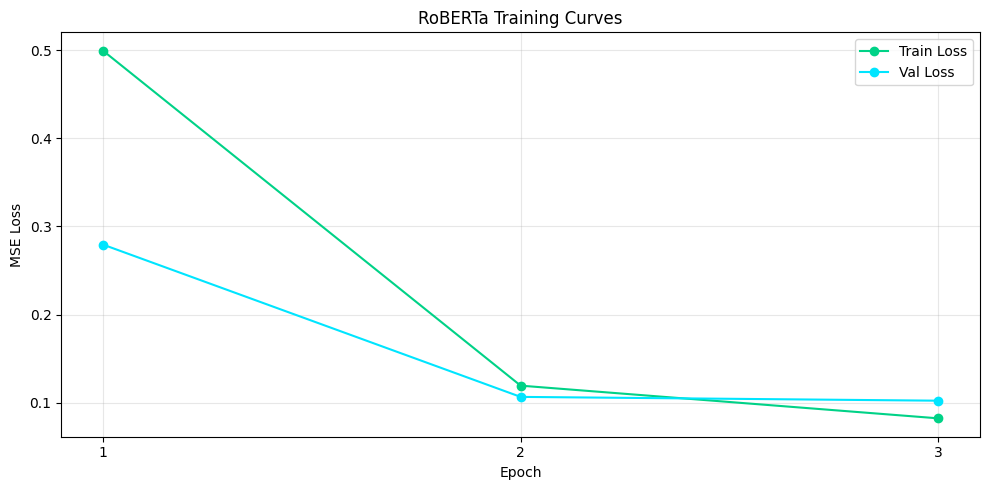

In [7]:
# ── Training Curves ──
plt.figure(figsize=(10, 5))
plt.plot(range(1, EPOCHS+1), train_losses, 'o-', label='Train Loss', color='#00d287')
plt.plot(range(1, EPOCHS+1), val_losses, 'o-', label='Val Loss', color='#00e5ff')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('RoBERTa Training Curves')
plt.legend()
plt.grid(alpha=0.3)
plt.xticks(range(1, EPOCHS+1))
plt.tight_layout()
plt.savefig(f'{MODEL_DIR}/roberta_training_curves.png', dpi=150)
plt.show()


  RoBERTa — TEST SET RESULTS
  MSE:  0.1016
  RMSE: 0.3188
  MAE:  0.2450
  R²:   0.9359


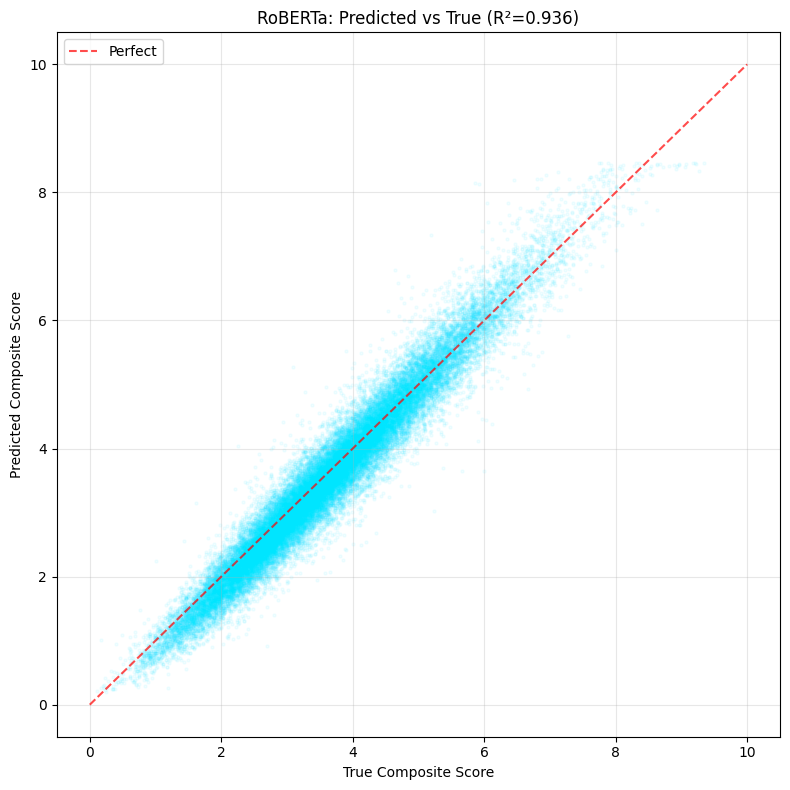

In [8]:
# ── Evaluate on Test Set ──
model.load_state_dict(torch.load(save_path))
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels']

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        preds = outputs.logits.squeeze(-1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

y_true = np.array(all_labels)
y_pred = np.array(all_preds)

mse  = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_true, y_pred)
r2   = r2_score(y_true, y_pred)

print("=" * 50)
print("  RoBERTa — TEST SET RESULTS")
print("=" * 50)
print(f"  MSE:  {mse:.4f}")
print(f"  RMSE: {rmse:.4f}")
print(f"  MAE:  {mae:.4f}")
print(f"  R²:   {r2:.4f}")
print("=" * 50)

# Scatter plot
plt.figure(figsize=(8, 8))
plt.scatter(y_true, y_pred, alpha=0.05, s=5, color='#00e5ff')
plt.plot([0, 10], [0, 10], 'r--', alpha=0.7, label='Perfect')
plt.xlabel('True Composite Score')
plt.ylabel('Predicted Composite Score')
plt.title(f'RoBERTa: Predicted vs True (R²={r2:.3f})')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{MODEL_DIR}/roberta_scatter.png', dpi=150)
plt.show()


In [9]:
# ── Save Model for Inference ──
model.save_pretrained(f'{MODEL_DIR}/roberta_creativity_model')
tokenizer.save_pretrained(f'{MODEL_DIR}/roberta_creativity_model')

# Also save the test metrics
import json
metrics = {'mse': mse, 'rmse': rmse, 'mae': mae, 'r2': r2}
with open(f'{MODEL_DIR}/roberta_test_metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)

print(f"Model saved to {MODEL_DIR}/roberta_creativity_model/")
print(f"Metrics saved to {MODEL_DIR}/roberta_test_metrics.json")
print("\n✅ Done! Download the model folder to your local project.")


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to ..\data\models/roberta_creativity_model/
Metrics saved to ..\data\models/roberta_test_metrics.json

✅ Done! Download the model folder to your local project.
